Import Libraries

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

Define Dataset Path

In [5]:
train_dir = "../dataset/Training"
test_dir = "../dataset/Testing"

Check Class Names

In [6]:
classes = os.listdir(train_dir)

print("Classes:")
print(classes)

Classes:
['glioma', 'meningioma', 'notumor', 'pituitary']


Count Images in Each Class

In [7]:
train_counts = {}

for cls in classes:
    class_path = os.path.join(train_dir, cls)
    train_counts[cls] = len(os.listdir(class_path))

train_counts

{'glioma': 1400, 'meningioma': 1400, 'notumor': 1400, 'pituitary': 1400}

Create a DataFrame

In [8]:
df = pd.DataFrame(
    train_counts.items(),
    columns=["Class", "Images"]
)

df

,Class,Images
0,glioma,1400
1,meningioma,1400
2,notumor,1400
3,pituitary,1400


Plot Class Distribution

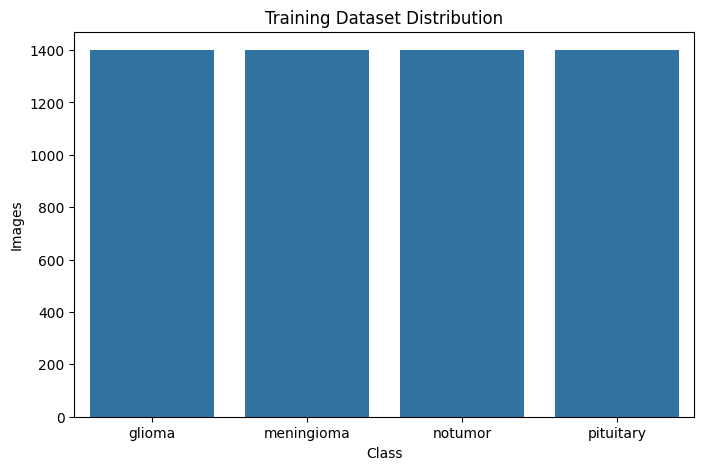

In [9]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Class",
    y="Images",
    data=df
)

plt.title("Training Dataset Distribution")
plt.show()

Pie Chart

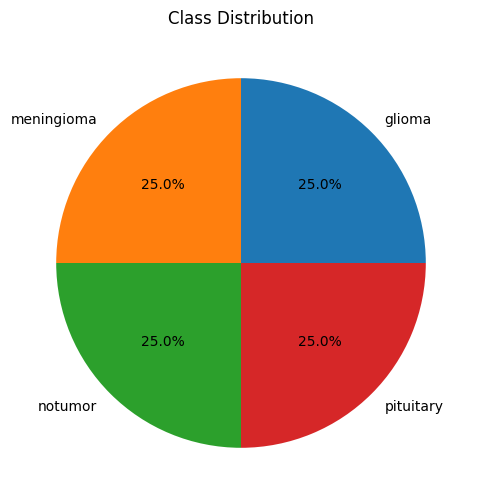

In [10]:
plt.figure(figsize=(6,6))

plt.pie(
    df["Images"],
    labels=df["Class"],
    autopct="%1.1f%%"
)

plt.title("Class Distribution")
plt.show()

Display Sample Images

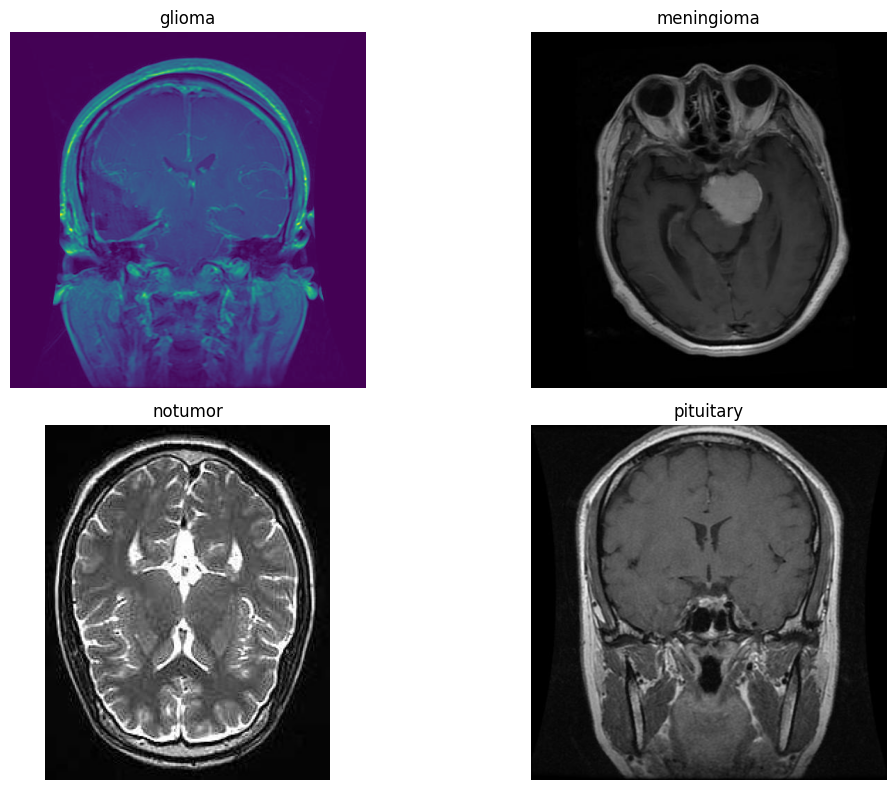

In [11]:
plt.figure(figsize=(12,8))

for i, cls in enumerate(classes):

    folder = os.path.join(train_dir, cls)

    image_name = os.listdir(folder)[0]

    image_path = os.path.join(folder, image_name)

    img = Image.open(image_path)

    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

Check Image Sizes

In [12]:
sizes = []

for cls in classes:

    folder = os.path.join(train_dir, cls)

    image_name = os.listdir(folder)[0]

    image_path = os.path.join(folder, image_name)

    img = Image.open(image_path)

    sizes.append(img.size)

sizes

[(512, 512), (512, 512), (201, 251), (512, 512)]

Observations:
- Dataset contains 4 classes.
- Class distribution is mostly balanced (or note any imbalance).
- MRI images have varying/similar dimensions.
- Images are grayscale/RGB depending on the dataset.
- Preprocessing will include resizing, normalization, and augmentation.

<h3 style = color:green>Image Preprocessing and Data Augmentation</h3>

Import Required libraries

In [13]:
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

Define Image Parameters

In [14]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

Create Training Data Generator

In [15]:
train_datagen = ImageDataGenerator(
    rescale=1./255,

    validation_split=0.2,

    rotation_range=20,

    width_shift_range=0.2,

    height_shift_range=0.2,

    shear_range=0.2,

    zoom_range=0.2,

    horizontal_flip=True,

    fill_mode='nearest'
)

Create Validation Generator

In [16]:
validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

Create Training Dataset

In [17]:
train_generator = train_datagen.flow_from_directory(
    train_dir,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='training',

    shuffle=True
)

Found 4480 images belonging to 4 classes.


Create Validation Dataset

In [18]:
validation_generator = validation_datagen.flow_from_directory(
    train_dir,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='validation',

    shuffle=False
)

Found 1120 images belonging to 4 classes.


Create Test Dataset

In [19]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    shuffle=False
)

Found 1600 images belonging to 4 classes.


Check Dataset information

In [20]:
print("Training Images :", train_generator.samples)

print("Validation Images :", validation_generator.samples)

print("Testing Images :", test_generator.samples)


Training Images : 4480
Validation Images : 1120
Testing Images : 1600


Check Class Indises

In [21]:
{
 'glioma': 0,
 'meningioma': 1,
 'notumor': 2,
 'pituitary': 3
}

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

Diaplay Augmented images

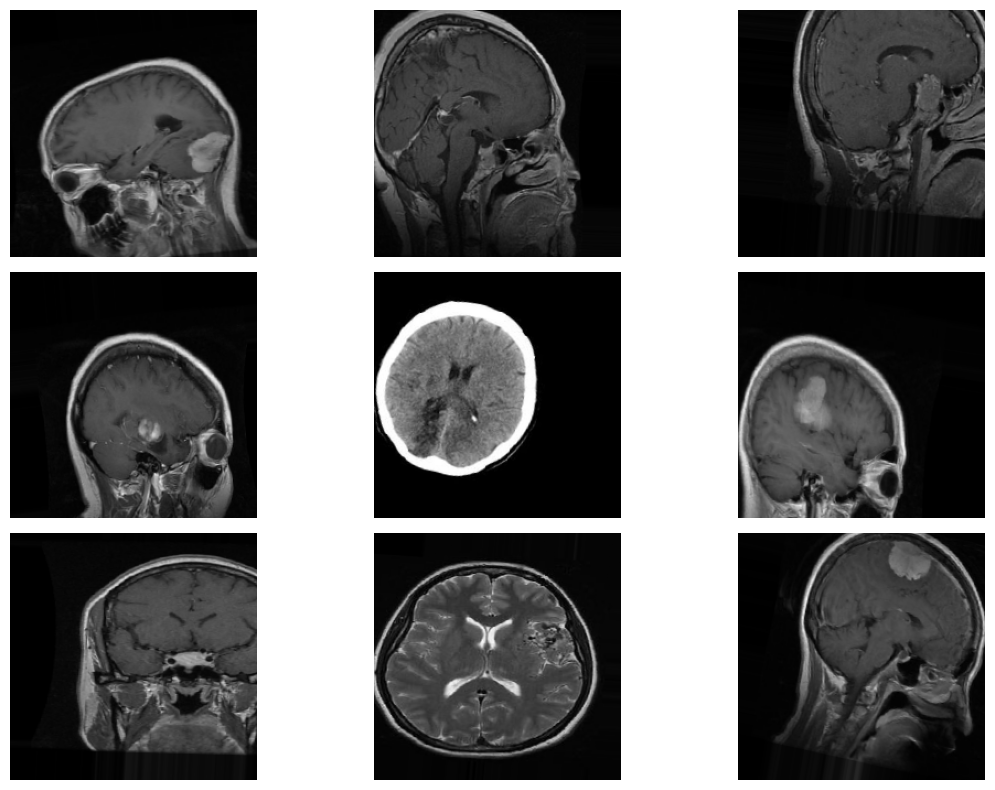

In [22]:
images, labels = next(train_generator)

plt.figure(figsize=(12,8))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    plt.axis("off")

plt.tight_layout()

plt.show()

Check Badge Shape

In [23]:
print(images.shape)
print(labels.shape)

(32, 224, 224, 3)
(32, 4)


<h3 style = color:green>Build the Brain Tumor Classification Model</h3>

Objective
In this step, we will:

- Load the pretrained MobileNetV2 model
- Freeze its base layers
- Add a custom classification head
- Compile the model
- View the model summary

Import Libraries

In [24]:
from tensorflow.keras.applications import MobileNetV2

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

from tensorflow.keras.models import Model

Load Pretrained MobileNetV2

In [25]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

Freeze Base layers

In [26]:
for layer in base_model.layers:
    layer.trainable = False

Build the Custom Classification Head

In [27]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)

x = Dropout(0.5)(x)

predictions = Dense(
    4,
    activation='softmax'
)(x)

Crete the Final Model

In [28]:
model = Model(
    inputs=base_model.input,
    outputs=predictions
)

Display Model Summary

In [29]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,586,948 (9.87 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Compile the Model

In [30]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

Verify Trainable Parameters

In [31]:
print("Trainable Layers:")

for layer in model.layers:
    if layer.trainable:
        print(layer.name)

Trainable Layers:
global_average_pooling2d
dense
dropout
dense_1


<h2 style = color:green>Train the Model</h2>

Objective
In this step, we will:

- Add callbacks (EarlyStopping & ModelCheckpoint)
- Train the model
- Save the best model automatically
- Plot training history
- Analyze learning curves

Import Required Libraries

In [32]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

Create Folder to Save Model

In [33]:
import os

os.makedirs("../saved_model", exist_ok=True)

Early Stopping

- Early stopping prevents unnecessary training once the validation loss stops improving.

In [34]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

Model Checkpoint

In [35]:
checkpoint = ModelCheckpoint(
    "../saved_model/brain_tumor_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

Train the Model

In [36]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=[
        early_stop,
        checkpoint
    ]
)

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6639 - loss: 0.8609 - precision: 0.7200 - recall: 0.6014
Epoch 1: val_accuracy improved from None to 0.82232, saving model to ../saved_model/brain_tumor_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 227s 2s/step - accuracy: 0.7574 - loss: 0.6225 - precision: 0.8004 - recall: 0.7105 - val_accuracy: 0.8223 - val_loss: 0.4665 - val_precision: 0.8352 - val_recall: 0.8009
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8369 - loss: 0.4329 - precision: 0.8594 - recall: 0.8153
Epoch 2: val_accuracy improved from 0.82232 to 0.82589, saving model to ../saved_model/brain_tumor_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 216s 2s/step - accuracy: 0.8420 - loss: 0.4275 - precision: 0.8624 - recall: 0.8210 - val_accuracy: 0.8259 - val_loss: 0.4370 - val_precision: 0.8424 - val_recall: 0.8062
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8489 - loss: 0.3949 - precision: 0.8676 - recall: 0.8232
Epoch 3: val_ac

View Training History

In [38]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'precision', 'recall', 'val_accuracy', 'val_loss', 'val_precision', 'val_recall'])

Plot Accuracy

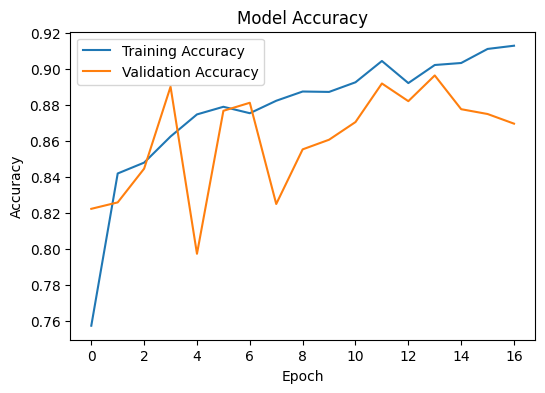

In [39]:
plt.figure(figsize=(6,4))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

Plot Loss

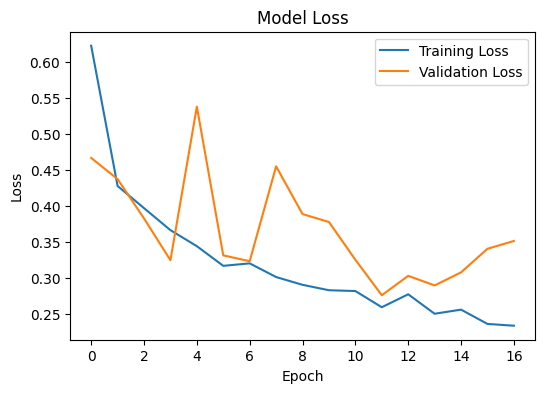

In [40]:
plt.figure(figsize=(6,4))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

Plot Precision

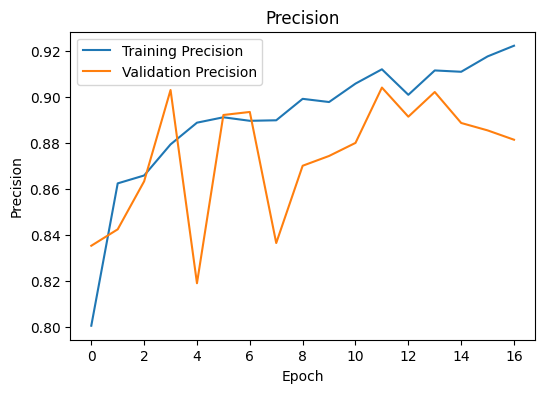

In [41]:
plt.figure(figsize=(6,4))

plt.plot(history.history['precision'], label='Training Precision')
plt.plot(history.history['val_precision'], label='Validation Precision')

plt.title("Precision")
plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.legend()

plt.show()

Plot Recall

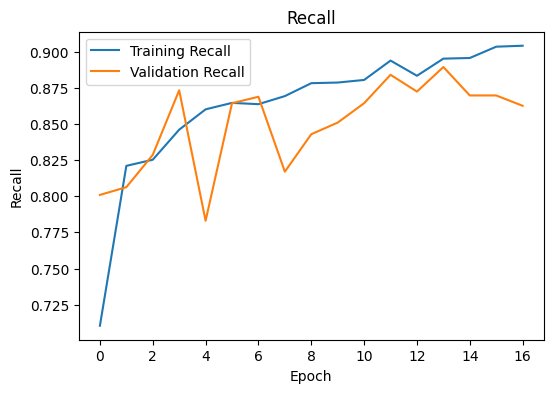

In [42]:
plt.figure(figsize=(6,4))

plt.plot(history.history['recall'], label='Training Recall')
plt.plot(history.history['val_recall'], label='Validation Recall')

plt.title("Recall")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.legend()

plt.show()

<h3 style = color:green>Model Evaluation</h3>
Objective

In this step, we will:

- Load the best saved model
- Predict on the test dataset
- Generate a confusion matrix
- Create a classification report
- Calculate Precision, Recall, F1-Score
- Plot ROC-AUC curves (multi-class)

Import Required Libraries

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import load_model

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

Load the Saved Model

In [44]:
model = load_model("../saved_model/brain_tumor_model.keras")

Evaluate on Test Dataset

In [45]:
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(test_generator)

print("Test Accuracy :", test_accuracy)
print("Test Precision :", test_precision)
print("Test Recall :", test_recall)

50/50 ━━━━━━━━━━━━━━━━━━━━ 51s 932ms/step - accuracy: 0.8425 - loss: 0.5448 - precision: 0.8528 - recall: 0.8363
Test Accuracy : 0.8424999713897705
Test Precision : 0.8527724742889404
Test Recall : 0.8362500071525574


Make Predictions

In [46]:
predictions = model.predict(test_generator)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator.classes

class_labels = list(test_generator.class_indices.keys())

50/50 ━━━━━━━━━━━━━━━━━━━━ 50s 964ms/step


Confusion Matrix

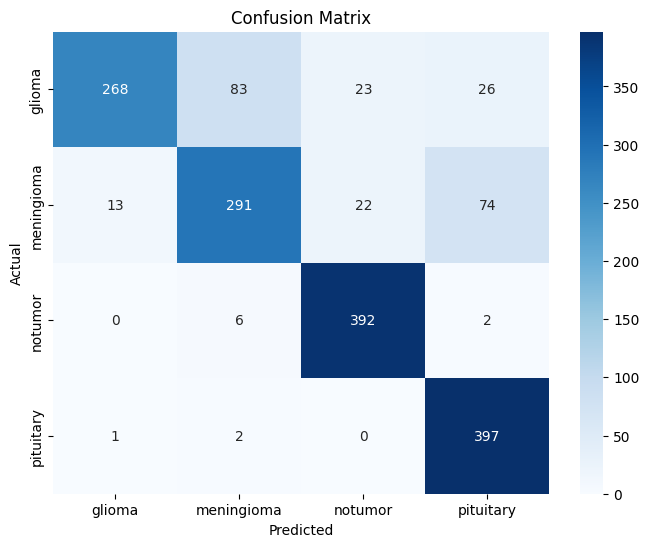

In [47]:
cm = confusion_matrix(
    true_classes,
    predicted_classes
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

Clasification Report

In [48]:
print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
))

              precision    recall  f1-score   support

      glioma       0.95      0.67      0.79       400
  meningioma       0.76      0.73      0.74       400
     notumor       0.90      0.98      0.94       400
   pituitary       0.80      0.99      0.88       400

    accuracy                           0.84      1600
   macro avg       0.85      0.84      0.84      1600
weighted avg       0.85      0.84      0.84      1600



ROC-AUC Curve

In [49]:
y_true = label_binarize(
    true_classes,
    classes=[0,1,2,3]
)

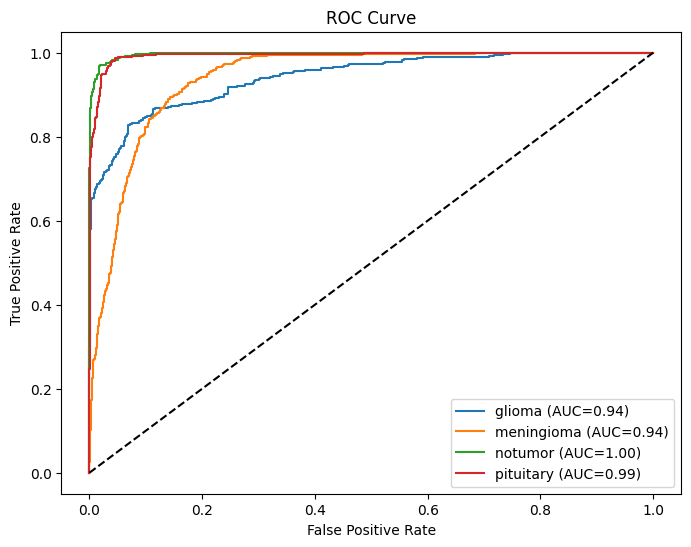

In [50]:
plt.figure(figsize=(8,6))

for i in range(4):

    fpr, tpr, _ = roc_curve(
        y_true[:, i],
        predictions[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_labels[i]} (AUC={roc_auc:.2f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

<h2 style = color:green>Predict on a New MRI Image</h2>

Objective

We will:

- Load the trained model
- Load a new MRI image
- Preprocess it
- Predict the tumor type
- Display the confidence score
- Show the uploaded image with the prediction

Import required Libraries

In [51]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

Load the Saved Model

In [52]:
model = load_model("../saved_model/brain_tumor_model.keras")

Class Names

In [53]:
class_names = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

In [54]:
print(train_generator.class_indices)

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


Load a Test Image

In [55]:
img_path = "C:/Medical-Image-Classification/dataset/Testing/meningioma/Te-aug-me_7.jpg"

Preprocessed the Image

In [56]:
img = image.load_img(
    img_path,
    target_size=(224,224)
)

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(
    img_array,
    axis=0
)

Make Predictions

In [57]:
prediction = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


Get Predicted Class

In [58]:
predicted_class = np.argmax(prediction)

predicted_label = class_names[predicted_class]

confidence = np.max(prediction)

Print Prediction

In [59]:
print("Predicted Class :", predicted_label)

print("Confidence :", confidence*100,"%")

Predicted Class : meningioma
Confidence : 73.26124 %


Display The Image

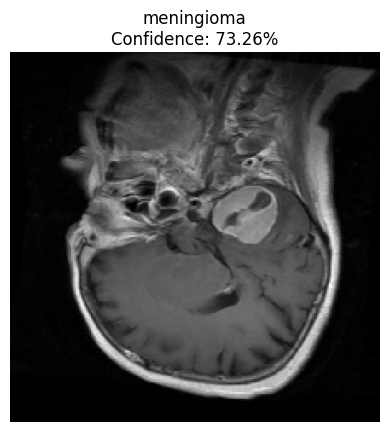

In [60]:
plt.imshow(img)

plt.axis("off")

plt.title(
    f"{predicted_label}\nConfidence: {confidence*100:.2f}%"
)

plt.show()

In [61]:
import sys
import tensorflow as tf
import keras

print(sys.executable)
print(tf.__version__)
print(keras.__version__)

c:\Medical-Image-Classification\venv\Scripts\python.exe
2.21.0
3.12.4
